In [8]:
import roboticstoolbox as rtb
import spatialmath as sm
import numpy as np
import matplotlib.pyplot as plt

In [9]:
# TODO: Fill in the correct parameters from the UR website

link1 = rtb.RevoluteDH(d=0.15185, a=0.0, alpha=np.pi/2)
link2 = rtb.RevoluteDH(d=0.0, a=-0.24355, alpha=0.0)
link3 = rtb.RevoluteDH(d=0.0, a=-0.2132, alpha=0.0)
link4 = rtb.RevoluteDH(d=0.13105, a=0.0, alpha=np.pi/2)
link5 = rtb.RevoluteDH(d=0.08535, a=0.0, alpha=-np.pi/2)
link6 = rtb.RevoluteDH(d=0.0921, a=0.0, alpha=0.0)
# Create the robot object
my_ur3e = rtb.DHRobot([link1, link2, link3, link4, link5, link6], name="My_UR3e")

print(my_ur3e)

DHRobot: My_UR3e, 6 joints (RRRRRR), dynamics, standard DH parameters
┌─────┬─────────┬─────────┬────────┐
│ θⱼ  │   dⱼ    │   aⱼ    │   ⍺ⱼ   │
├─────┼─────────┼─────────┼────────┤
│  q1 │  0.1519 │       0 │  90.0° │
│  q2 │       0 │ -0.2435 │   0.0° │
│  q3 │       0 │ -0.2132 │   0.0° │
│  q4 │   0.131 │       0 │  90.0° │
│  q5 │ 0.08535 │       0 │ -90.0° │
│  q6 │  0.0921 │       0 │   0.0° │
└─────┴─────────┴─────────┴────────┘

┌──┬──┐
└──┴──┘



In [29]:
# 1. Define Start and End joint configurations
q_start = np.array([0] * 6)           # Robot straight out
q_end   = np.array([100*np.pi] * 6) # Robot folded 90 degrees

# 2. Generate trajectory (50 steps)
traj = rtb.jtraj(q_start, q_end, 100, )

# traj.q contains the 50x2 array of joint angles for the path
print("Shape of trajectory:", traj.q.shape)

# 3. Visualize the movement
# This will animate the robot moving through the path
# my_ur3e.plot(traj.q, backend='pyplot')

Shape of trajectory: (100, 6)


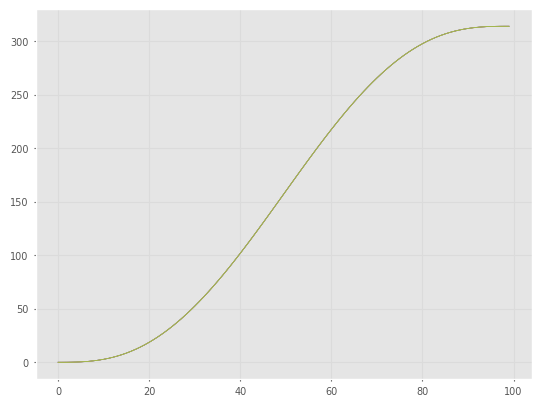

In [30]:
plt.plot(traj.q[:, :])

In [ ]:
class KinematicModel:
    def __init__(self):
        self.time = 0.0
        self.current_joint_angles = [0] * 6
        self.target_joint_angles = [0] * 6

        # Experiment variables
        self.start_time = 0.0
        self.stop_time = 0.0

        # Setup provided kinematic model
        link1 = rtb.RevoluteDH(d=0.15185, a=0.0, alpha=np.pi/2)
        link2 = rtb.RevoluteDH(d=0.0, a=-0.24355, alpha=0.0)
        link3 = rtb.RevoluteDH(d=0.0, a=-0.2132, alpha=0.0)
        link4 = rtb.RevoluteDH(d=0.13105, a=0.0, alpha=np.pi/2)
        link5 = rtb.RevoluteDH(d=0.08535, a=0.0, alpha=-np.pi/2)
        link6 = rtb.RevoluteDH(d=0.0921, a=0.0, alpha=0.0)
        # Create the robot object
        self.robot = rtb.DHRobot([link1, link2, link3, link4, link5, link6], name="robot")

    def _determine_movement_duration(self, start_angles: list, end_angles: list) -> float:
        # Calculate angle difference
        # angle_diffs = np.abs(np.array(start_angles) - np.array(end_angles))
        ...

        

    def fmi2SetupExperiment(self, start_time: float, stop_time: float):
        self.start_time = start_time
        self.stop_time = stop_time

    def fmi2Instantiate(self):
        self.time = 0.0
        self.current_joint_angles = [0] * 6
        self.target_joint_angles = [0] * 6

    def fmi2DoStep(self, current_time, step_size):
        self.time = current_time + step_size

        if np.abs(self.v) < self.max_v:
            self.v = self.v + step_size * self.acc
        else:
            self.v = self.v_max

        self.x = self.x + step_size * self.v

        
    
    def fmi2Terminate(self):
        ...
    
